## Дз 2. Аналоговые фильтры
**Вариант 2. Бакулев Семён**

$$
x(t)=
\frac{a_2}{b_2 + \left|t - t_2\right|}
\exp\!\left(-c_2 \left|t - t_3\right|\right)
\,\mathrm{sinc}(d_2 t)
$$

Параметры:
```
a2 = -5
b2 =  2
t2 = -2
c2 =  0.4
t3 = -1
d2 =  9
```

## Идеальный полосовой фильтр
Его цель — удаление из сигнала ярко выраженных колебаний.

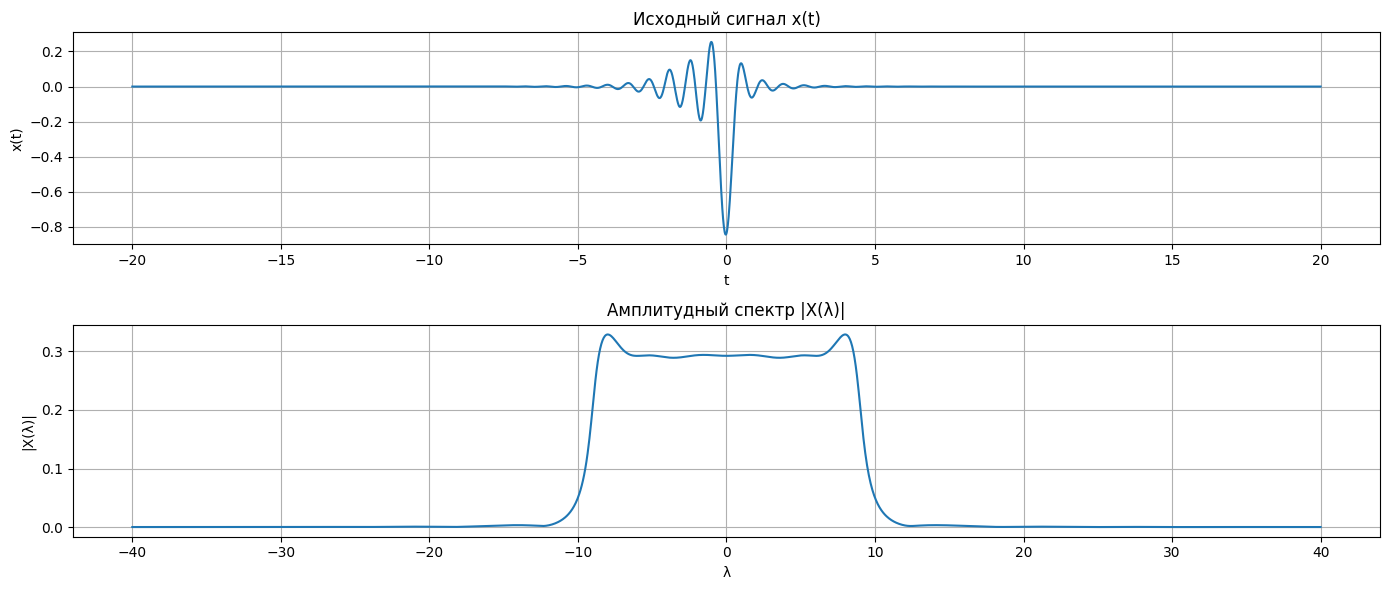

In [127]:
import numpy as np
import matplotlib.pyplot as plt

# Параметры сигнала
a2 = -5
b2 = 2
t2 = -2
c2 = 0.4
t3 = -1
d2 = 9


# Функция сигнала
def x(t):
    return (
        (a2 / (b2 + np.abs(t - t2)))
        * np.exp(-c2 * np.abs(t - t3))
        * np.sinc(d2 * t / np.pi)
    )

# Параметры
N = 3000
M = 2000
lambda_min, lambda_max = -40, 40
t_min, t_max = -20, 20

# Частотная сетка
lambdas = np.linspace(lambda_min, lambda_max, M)
dlambdas = lambdas[1] - lambdas[0]

# Сетка по времени
t = np.linspace(t_min, t_max, N)
dt = t[1] - t[0]

x_vals = x(t)

plt.figure(figsize=(14, 6))
plt.subplot(2, 1, 1)
plt.plot(t, x_vals, label="Исходный сигнал")
plt.title("Исходный сигнал x(t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

E_forward = np.exp(-1j * np.outer(lambdas, t))  # M x N
X_vals = E_forward @ x_vals * dt  # M

plt.subplot(2, 1, 2)
plt.plot(lambdas, np.abs(X_vals))
plt.title("Амплитудный спектр |X(λ)|")
plt.xlabel("λ")
plt.ylabel("|X(λ)|")
plt.grid(True)

plt.tight_layout()
plt.show()

В исходном сигнале колбеания задаются компонентой $\mathrm{sinc}(9t)$, поэтому "осцилирующая" часть связана с частотами порядка $|\lambda|≈9$. По графику амплитудного спектра для этого сигнала наиболее заметные пики действительно оказываются около $λ≈\pm8...\pm9$, поэтому возьмём полосу пропускания чуть уже, чем эти частоты, например: $[−λ_F​,λ_F​]=[−6,6]$, чтобы отбросить эти выраженные пики.

#### Фильтрция через ПФ (идея)
1. Находим спектр сигнала
2. Умножаем на фильтр
3. Делаем обратное ПФ, чтобы получить новый сигнал
#### Фильтрция через свёртку (идея)
Фильтр действует во времени, каждая точка сигнала получается как “смешивание” соседних значений.

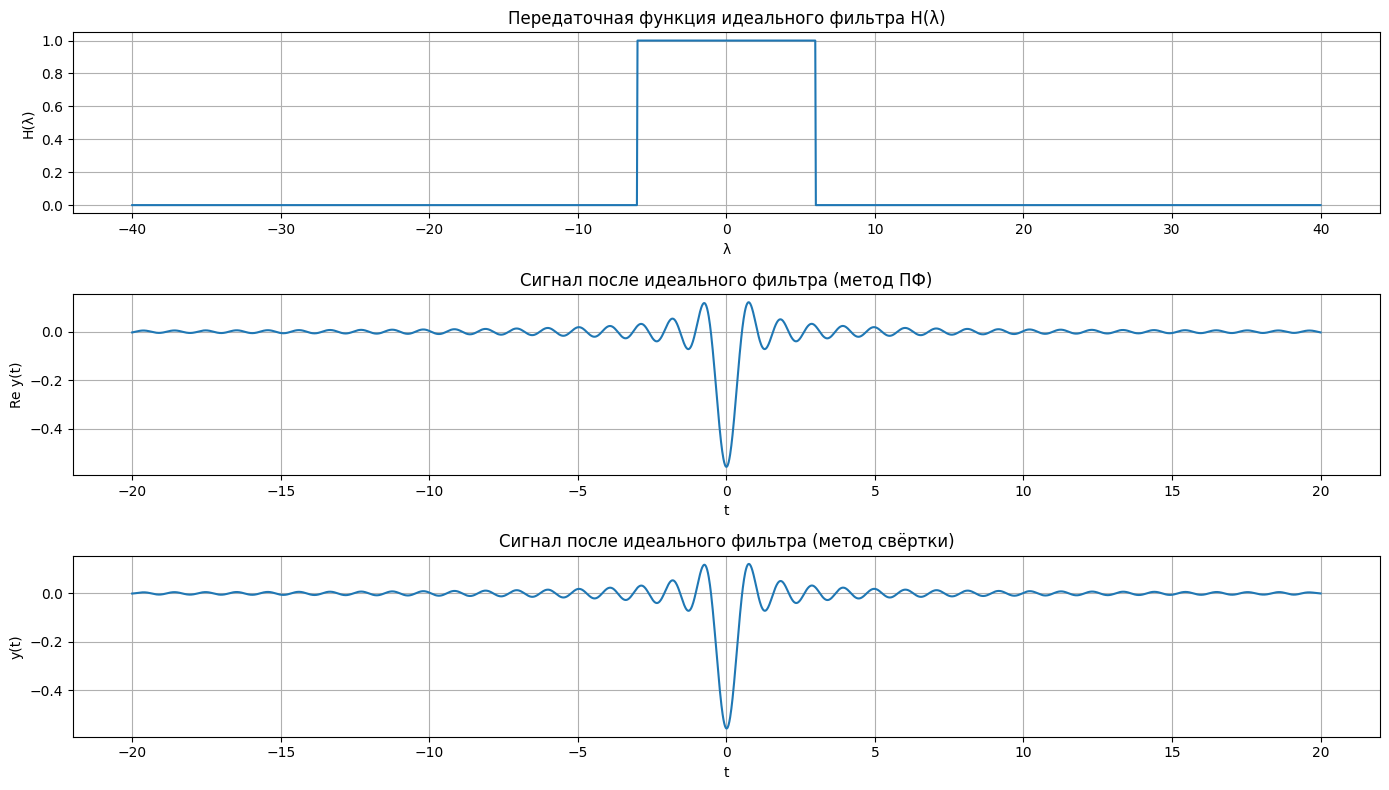

In [128]:
lambda_F = 6.0
H_ideal = np.where(np.abs(lambdas) <= lambda_F, 1.0, 0.0)

plt.figure(figsize=(14, 8))

plt.subplot(3, 1, 1)
plt.plot(lambdas, H_ideal)
plt.title("Передаточная функция идеального фильтра H(λ)")
plt.xlabel("λ")
plt.ylabel("H(λ)")
plt.grid(True)

Y = X_vals * H_ideal

E_inverse = np.exp(1j * np.outer(t, lambdas))  # N x M
y_ideal_fourier = (E_inverse @ Y) * dlambdas / (2 * np.pi)

def h_ideal(t, lam_F):
    h = np.empty_like(t)
    mask = np.abs(t) > 1e-12
    h[mask] = np.sin(lam_F * t[mask]) / (np.pi * t[mask])
    h[~mask] = lam_F / np.pi
    return h


h_vals = h_ideal(t, lambda_F)

plt.subplot(3, 1, 2)
plt.plot(t, np.real(y_ideal_fourier), label="После фильтра (через ПФ)")
plt.title("Сигнал после идеального фильтра (метод ПФ)")
plt.xlabel("t")
plt.ylabel("Re y(t)")
plt.grid(True)

y_ideal_conv = dt * np.convolve(x_vals, h_vals, mode="same")
plt.subplot(3, 1, 3)
plt.plot(t, y_ideal_conv, label="После фильтра (через свёртку)")
plt.title("Сигнал после идеального фильтра (метод свёртки)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

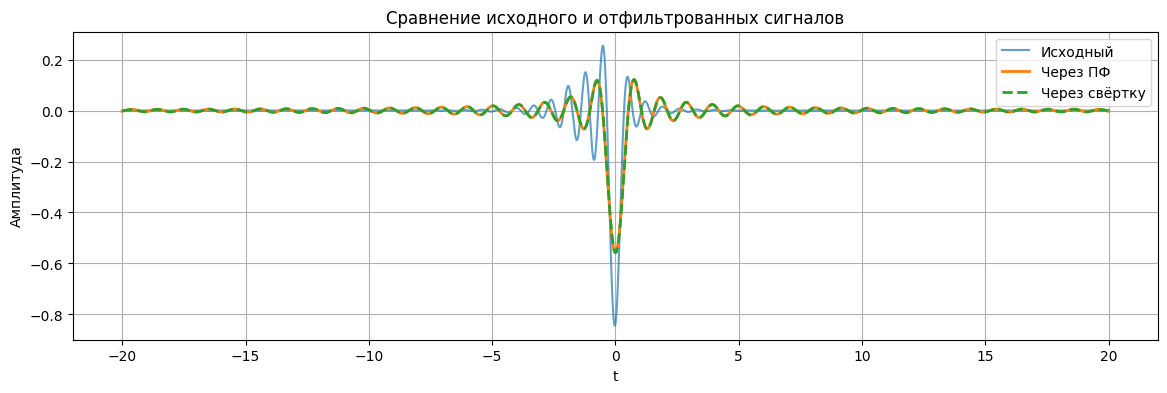

In [129]:
plt.figure(figsize=(14, 4))
plt.plot(t, x_vals, label="Исходный", alpha=0.7)
plt.plot(t, np.real(y_ideal_fourier), label="Через ПФ", linewidth=2)
plt.plot(t, y_ideal_conv, "--", label="Через свёртку", linewidth=2)
plt.title("Сравнение исходного и отфильтрованных сигналов")
plt.xlabel("t")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

In [130]:
mae_vs_original = np.mean(np.abs(np.real(y_ideal_fourier) - x_vals))
maxdiff_methods = np.max(np.abs(np.real(y_ideal_fourier) - y_ideal_conv))
mae_methods = np.mean(np.abs(np.real(y_ideal_fourier) - y_ideal_conv))

print("Параметры расчета:")
print(f"t in [{t_min}, {t_max}], λ in [{lambda_min}, {lambda_max}]")
print(f"N = {N}, M = {M}, Δt = {dt}, Δλ = {dlambdas}")
print(f"Выбранная полоса пропускания: [-{lambda_F}, {lambda_F}]")

print("\nОценки:")
print(f"Среднее |y_fourier - x| = {mae_vs_original}")
print(f"Макс |y_fourier - y_conv| = {maxdiff_methods}")
print(f"Среднее |y_fourier - y_conv| = {mae_methods}")


Параметры расчета:
t in [-20, 20], λ in [-40, 40]
N = 3000, M = 2000, Δt = 0.013337779259753546, Δλ = 0.04002001000500144
Выбранная полоса пропускания: [-6.0, 6.0]

Оценки:
Среднее |y_fourier - x| = 0.019035144257051127
Макс |y_fourier - y_conv| = 0.009883480929151228
Среднее |y_fourier - y_conv| = 0.0006545114400274275


Итак, заметим, что после фильтрации методом прямого и обратного преобразования Фурье сигнал **изменился** ($|y_fourier - x|=0.019$), он стал более гладким судя по графику: быстрые осцилляции заметно подавились, при этом медленная огибающая сохранилась.
При пропускании этого же сигнала через фильтр методом свёртки с функцией отклика результат практически совпадает. Есть небольшие численные различия результатов двух методов, однако они несуществуенны (в среднем 0.00065).

Если диапазон пропускания через фильтр увеличить, например, до 11, то исходный и обработанный сигнал станут намного ближе друг к другу, однако это нецелесообразно, так как фильтр перестаёт подавлять высокочастотные компоненты сигнала. При уменьшении диапазона, например, до 3, различия будут только увеличиваться.

## RC-цепочка как полосовой фильтр

Передаточная функция RC-цепочки определяется как отношение выходного сигнала к входному в частотной области:
$
H_{RC}(\lambda) = \frac{Y(\lambda)}{X(\lambda)}
$

После преобразований (дифференцирования уравнения цепи и перехода к частотной обдласти) получаем, что
$
H_{RC}(\lambda) = \frac{Y(\lambda)}{X(\lambda)} = \frac{1}{1 + i\lambda RC}
$

Граничная (характеристическая) частота RC-цепочки определяется как:
$
\lambda_c = \frac{1}{RC}
$

Поскольку мы хотим приблизить идеальный фильтр с полосой пропускания $[-\lambda_F, \lambda_F]$, то логичнее взять
$
\lambda_c \approx \lambda_F
$

Отсюда:
$
RC = \frac{1}{\lambda_F}
$

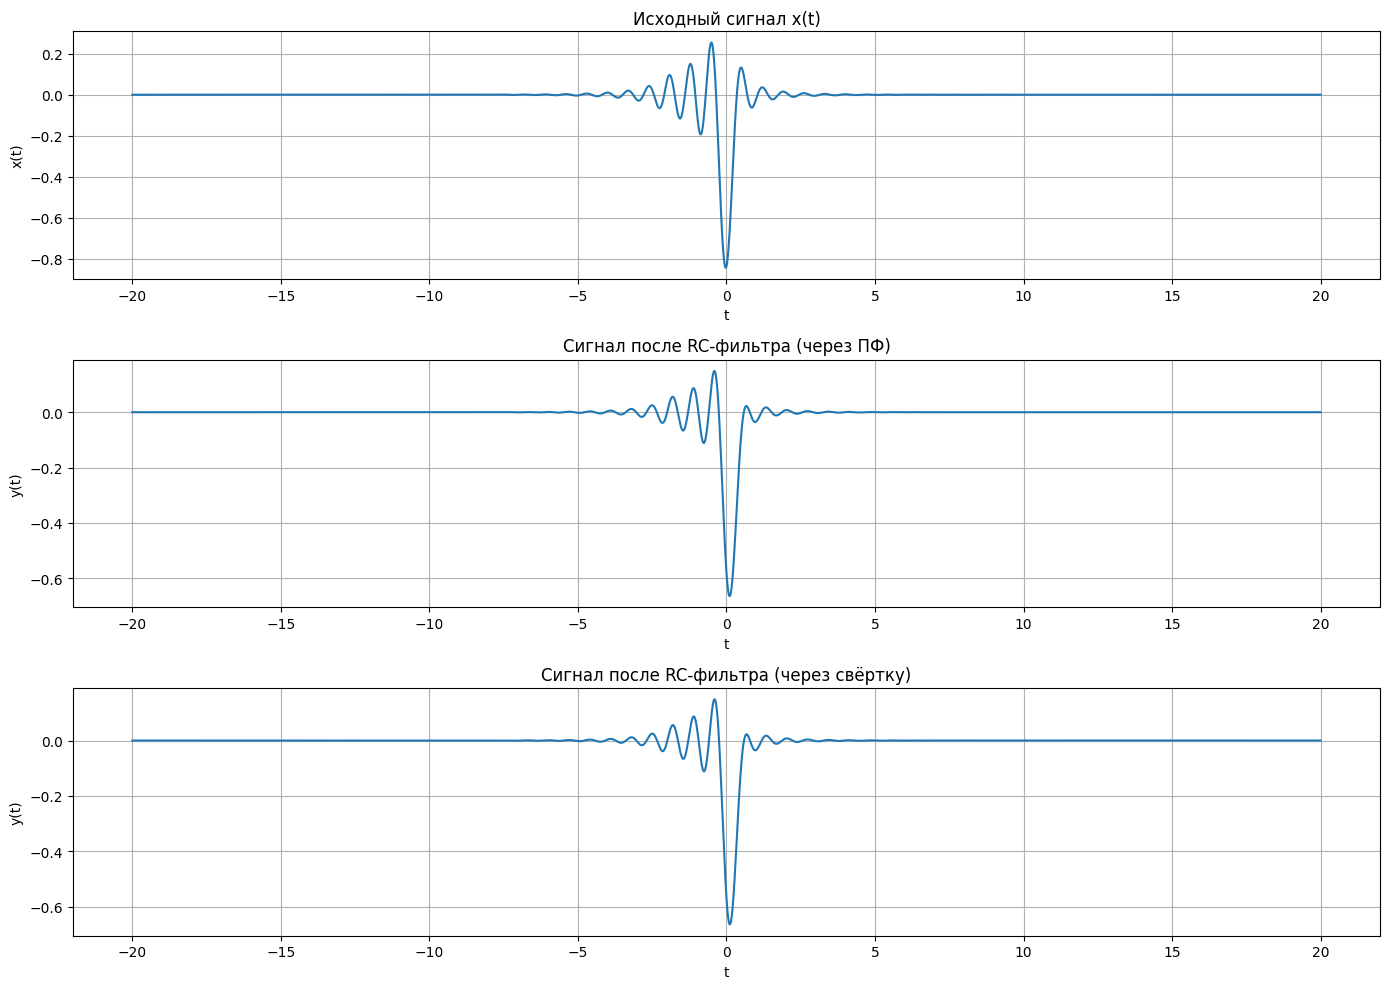

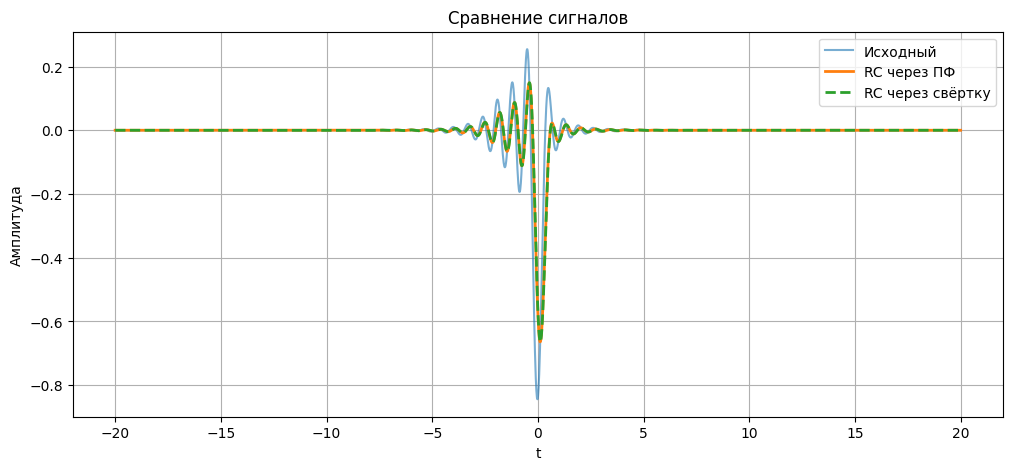

In [131]:
RC = 1 / lambda_F
# RC фильтр (в частотной области)
H_rc = 1 / (1 + 1j * lambdas * RC)

Y_rc = X_vals * H_rc
# Обратное ПФ
E_inverse = np.exp(1j * np.outer(t, lambdas))  # N x M
y_rc_fourier = (E_inverse @ Y_rc) * dlambdas / (2 * np.pi)

# Импульсная характеристика RC
def h_rc(t):
    h = np.zeros_like(t)
    mask = t >= 0
    h[mask] = (1 / RC) * np.exp(-t[mask] / RC)
    return h


h_vals = h_rc(t)
y_rc_conv = dt * np.convolve(x_vals, h_vals, mode="same")

plt.figure(figsize=(14, 10))

# Исходный сигнал
plt.subplot(3, 1, 1)
plt.plot(t, x_vals, label="Исходный сигнал")
plt.title("Исходный сигнал x(t)")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.grid(True)

# Через ПФ
plt.subplot(3, 1, 2)
plt.plot(t, np.real(y_rc_fourier), label="RC через ПФ")
plt.title("Сигнал после RC-фильтра (через ПФ)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)

# Через свёртку
plt.subplot(3, 1, 3)
plt.plot(t, y_rc_conv, label="RC через свёртку")
plt.title("Сигнал после RC-фильтра (через свёртку)")
plt.xlabel("t")
plt.ylabel("y(t)")
plt.grid(True)

plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, x_vals, label="Исходный", alpha=0.6)
plt.plot(t, np.real(y_rc_fourier), label="RC через ПФ", linewidth=2)
plt.plot(t, y_rc_conv, "--", label="RC через свёртку", linewidth=2)
plt.title("Сравнение сигналов")
plt.xlabel("t")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

In [132]:
print("Параметры:")
print("lambda_F =", lambda_F)
print("RC =", RC)
print("Δt =", dt)
print("Δλ =", dlambdas)

print("\nОценки:")
print(f"Среднее |RC_fourier - x| = {np.mean(np.abs(np.real(y_rc_fourier) - x_vals))}")
print(
    "Среднее |RC_fourier - RC_conv| =",
    np.mean(np.abs(np.real(y_rc_fourier) - y_rc_conv)),
)
print(
    "Макс |RC_fourier - RC_conv| =", np.max(np.abs(np.real(y_rc_fourier) - y_rc_conv))
)

Параметры:
lambda_F = 6.0
RC = 0.16666666666666666
Δt = 0.013337779259753546
Δλ = 0.04002001000500144

Оценки:
Среднее |RC_fourier - x| = 0.01146390503402237
Среднее |RC_fourier - RC_conv| = 0.0004647054580383108
Макс |RC_fourier - RC_conv| = 0.017239200228211737


Как и в идеальном фильтре разные методы фильтрации (через преобразование Фурье и через свёртку) дают практически совпадающие результаты. Т.е. в целом это соответствует общей теории фильтрации, что свёртка во времени эквивалентна умножению спектров в частотной области.

При этом отклонение *сигнала после RC-цепочки* от *исходного сигнала* оказывается **меньше**, чем в случае идеального фильтра. Это объясняется тем, что RC-фильтр ослабляет высокочастотные компоненты плавно, в отличие от идеального фильтра, который полностью отсекает их за пределами полосы.
Ниже на графиках это будет наглядно видно.

## Сравним RC-цепочку с идеальным полосовым фильтром

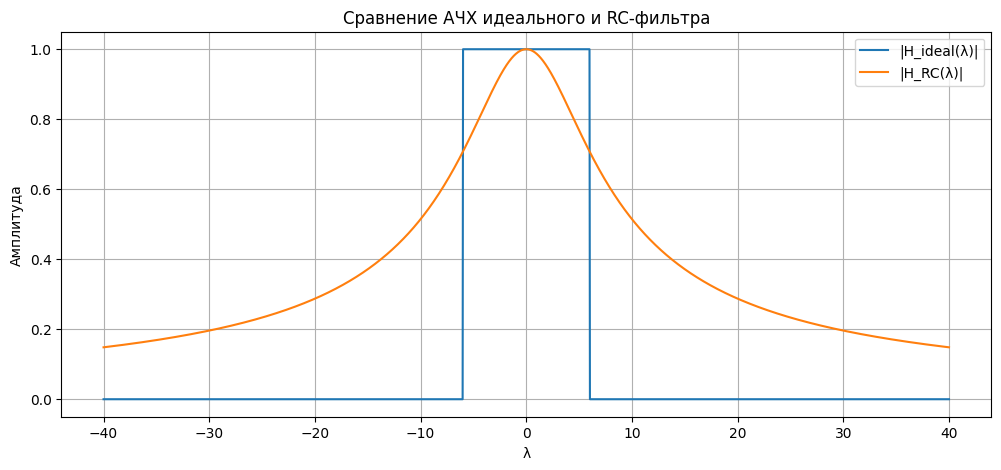

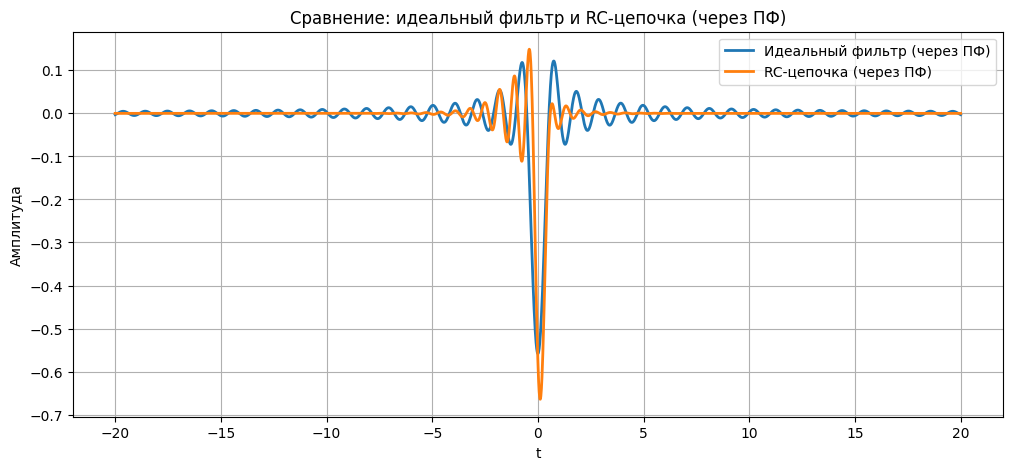

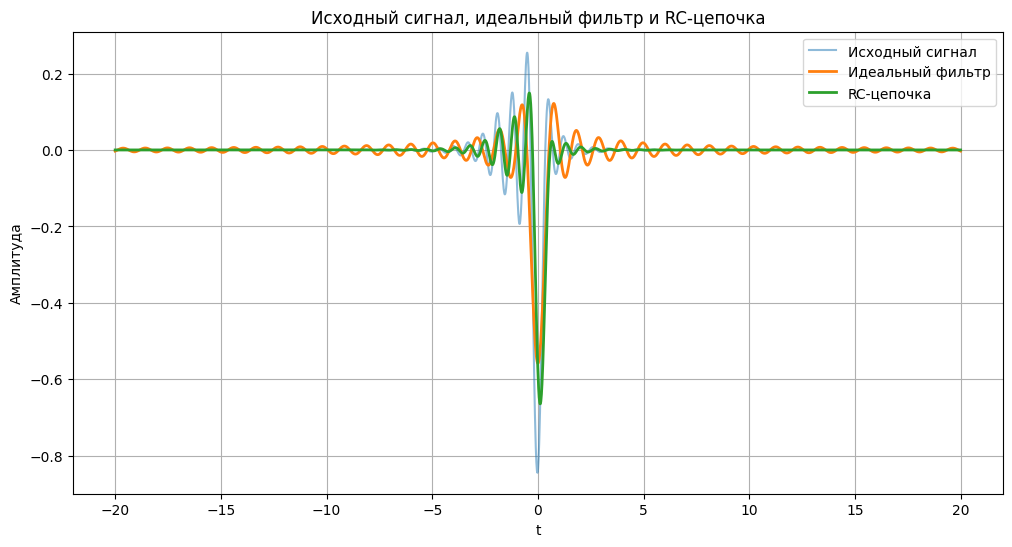

In [133]:
plt.figure(figsize=(12, 5))
plt.plot(lambdas, np.abs(H_ideal), label="|H_ideal(λ)|")
plt.plot(lambdas, np.abs(H_rc), label="|H_RC(λ)|")
plt.title("Сравнение АЧХ идеального и RC-фильтра")
plt.xlabel("λ")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(t, np.real(y_ideal_fourier), label="Идеальный фильтр (через ПФ)", linewidth=2)
plt.plot(t, np.real(y_rc_fourier), label="RC-цепочка (через ПФ)", linewidth=2)
plt.title("Сравнение: идеальный фильтр и RC-цепочка (через ПФ)")
plt.xlabel("t")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 6))
plt.plot(t, x_vals, label="Исходный сигнал", alpha=0.5)
plt.plot(t, np.real(y_ideal_fourier), label="Идеальный фильтр", linewidth=2)
plt.plot(t, np.real(y_rc_fourier), label="RC-цепочка", linewidth=2)
plt.title("Исходный сигнал, идеальный фильтр и RC-цепочка")
plt.xlabel("t")
plt.ylabel("Амплитуда")
plt.grid(True)
plt.legend()
plt.show()

In [134]:
print("Сравнение RC и идеального фильтра:")
print(
    "Среднее |y_rc_fourier - y_ideal_fourier| =",
    np.mean(np.abs(np.real(y_rc_fourier) - np.real(y_ideal_fourier))),
)
print("Среднее |y_rc_conv - y_ideal_conv| =", np.mean(np.abs(y_rc_conv - y_ideal_conv)))

print("\nСравнение двух методов для RC:")
print(
    "Среднее |y_rc_fourier - y_rc_conv| =",
    np.mean(np.abs(np.real(y_rc_fourier) - y_rc_conv)),
)
print(
    "Максимум |y_rc_fourier - y_rc_conv| =",
    np.max(np.abs(np.real(y_rc_fourier) - y_rc_conv)),
)


Сравнение RC и идеального фильтра:
Среднее |y_rc_fourier - y_ideal_fourier| = 0.016499651079395425
Среднее |y_rc_conv - y_ideal_conv| = 0.016452968084999076

Сравнение двух методов для RC:
Среднее |y_rc_fourier - y_rc_conv| = 0.0004647054580383108
Максимум |y_rc_fourier - y_rc_conv| = 0.017239200228211737


Как итог, RC-цепочка является лишь приближением идеального фильтра и не обеспечивает полного подавления высокочастотных компонент, однако сохраняет общий характер сглаживания сигнала. Тем не менее мы помним, что RC-фильтр является **физически реализуемой системой**, в отличие от идеального фильтра, который представляет собой лишь математическую модель.